In [1]:
import numpy as np
import matplotlib.pyplot as plt
from HybridPolynomial import ( BASE_POLYS,hybrid_correction,Chebyshev)
from PoissonFunctions import eigs_1d_poisson, build_1d_Poisson, eigs_2d_poisson
from HybridQSVT import QSVT

## Base polynomial and error

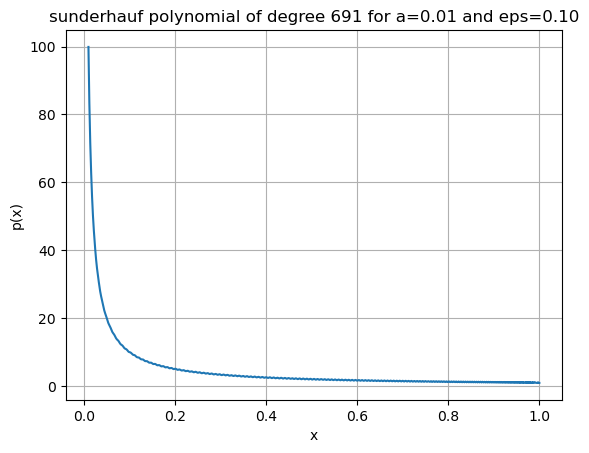

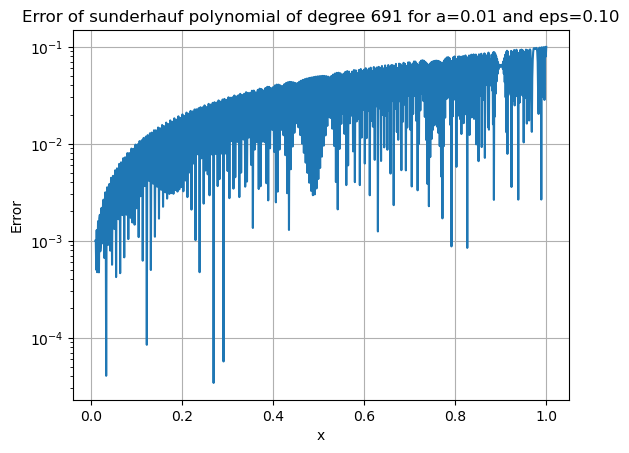

In [2]:
kappa = 100
eps = 0.1
a = 1/kappa
base = 'sunderhauf'
polyClass = BASE_POLYS[base.lower()]

degree   = polyClass.mindegree(eps, a)
poly = polyClass.poly(degree, a)

x = np.linspace(a, 1.0,1000)
y = poly(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title(f'{base} polynomial of degree {degree} for a={a:.2f} and eps={eps:.2f}')
plt.grid()
plt.show()

error = np.abs(x * poly(x) - 1.0)
plt.plot(x, error)
plt.xlabel('x')
plt.ylabel('Error')
plt.title(f'Error of {base} polynomial of degree {degree} for a={a:.2f} and eps={eps:.2f}')
plt.yscale('log')
plt.grid()
plt.show()

## Hybrid Polynomial 

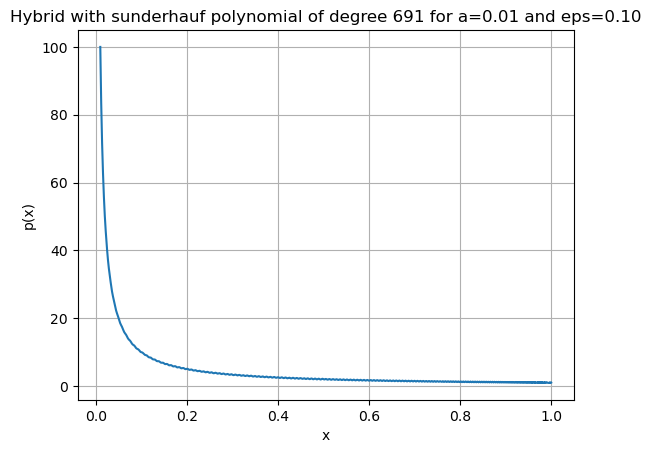

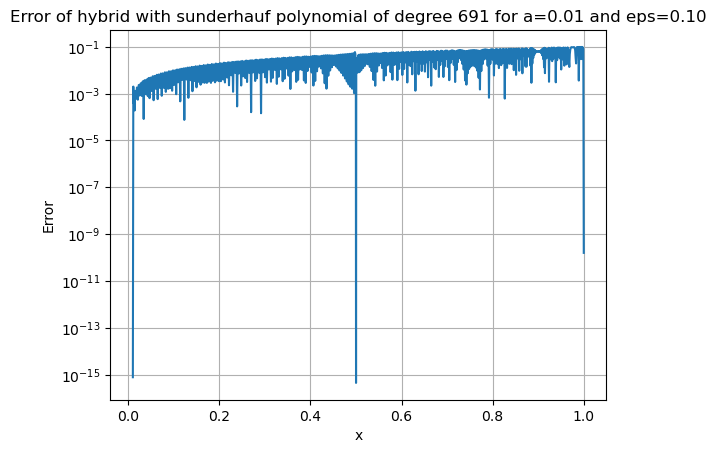

In [ ]:
kappa = 10
eps = 0.01
K = 3
lam = np.array([1/kappa, 0.5, 1])
basePolynomial  = 'sunderhauf' # 'remez' or 'mang' or 'sunderhauf'
polyClass = BASE_POLYS[basePolynomial.lower()]

degree   = polyClass.mindegree(eps, 1/kappa)
poly = polyClass.poly(degree, 1/kappa)

corr = hybrid_correction(poly,lam)
coef_H       = poly.coef.copy()
coef_H[1::2] += corr
hybrid_poly = Chebyshev(coef_H)


x = np.union1d(np.linspace(1/kappa, 1.0, 1000), lam)
y = hybrid_poly(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title(f'Hybrid with {basePolynomial} polynomial of degree {degree} for a={1/kappa:.2f} and eps={eps:.2f}')
plt.grid()
plt.show()

error = np.abs(x * hybrid_poly(x) - 1.0)
plt.plot(x, error)
plt.xlabel('x')
plt.ylabel('Error')
plt.title(f'Error of hybrid with {basePolynomial} polynomial of degree {degree} for a={1/kappa:.2f} and eps={eps:.2f}')
plt.yscale('log')
plt.grid()
plt.show()

## 1D Poisson Hybrid Correction

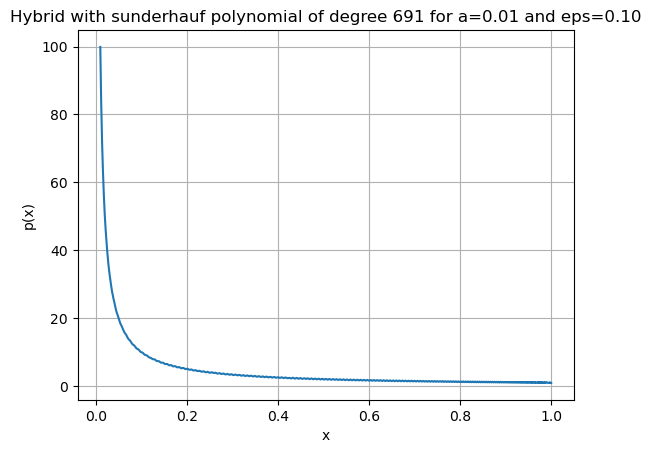

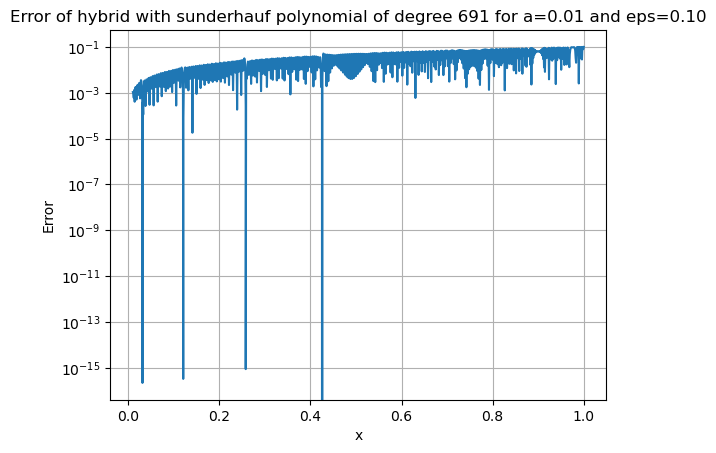

In [4]:
eps = 0.1
m = 3
all_lam  = eigs_1d_poisson(m)
N = m**2
K = int(N/2)
lam = all_lam[:K]
basePolynomial  = 'sunderhauf' # 'remez' or 'mang' or 'sunderhauf'
polyClass = BASE_POLYS[basePolynomial.lower()]

degree   = polyClass.mindegree(eps, a)
poly = polyClass.poly(degree, a)

corr = hybrid_correction(poly,lam)
coef_H       = poly.coef.copy()
coef_H[1::2] += corr
hybrid_poly = Chebyshev(coef_H)


x = np.union1d(np.linspace(a, 1.0, 1000), lam)
y = hybrid_poly(x)
plt.plot(x, y)
plt.xlabel('x')
plt.ylabel('p(x)')
plt.title(f'Hybrid with {basePolynomial} polynomial of degree {degree} for a={a:.2f} and eps={eps:.2f}')
plt.grid()
plt.show()

error = np.abs(x * hybrid_poly(x) - 1.0)
plt.plot(x, error)
plt.xlabel('x')
plt.ylabel('Error')
plt.title(f'Error of hybrid with {basePolynomial} polynomial of degree {degree} for a={a:.2f} and eps={eps:.2f}')
plt.yscale('log')
plt.grid()
plt.show()

## 1D Poisson QSVT; base polynomial

Condition number kappa=116.46119157748774
Generated 634 phase angles for degree 633
Circuit width: 10, depth: 1269
Running statevector simulation...
Success probability: 0.7023556545606844
Norm of real solution: 0.8297863102972018
Fidelity:            0.9999992867917521


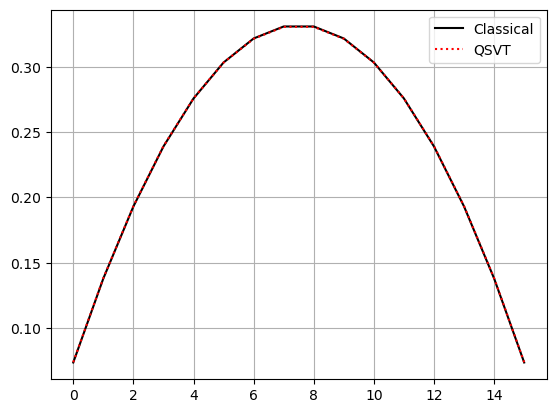

In [11]:
m = 4
eps = 0.01
basePolynomial ='mang'
A,b  = build_1d_Poisson(m, function_type="uniform")
lam = eigs_1d_poisson(m)
A = A / (1.01*np.max(lam))  # Scale to have max singular value < 1
kappa = np.max(lam) / np.min(lam)
print(f"Condition number kappa={kappa}")
# Classical Verification
u_classical = np.linalg.solve(A, b)
u_classical = u_classical / np.linalg.norm(u_classical)

solver = QSVT(A, b, kappa, target_error=eps, polyMethod=basePolynomial)

u_qsvt, success_prob, norm_real = solver.solve()
print("Success probability:", success_prob)
print("Norm of real solution:", norm_real)
print("Fidelity:           ", np.abs(np.dot(u_qsvt.conj(), u_classical))**2)

plt.plot(u_classical, 'k') 
plt.plot(u_qsvt, 'r:')
plt.legend(['Classical', 'QSVT'])
plt.grid()
plt.show()

## 1D Poisson; hybrid QSVT

In [ ]:
m = 4
eps = 0.01
basePolynomial ='mang'
A,b  = build_1d_Poisson(m, function_type="uniform")
lam = eigs_1d_poisson(m)
A = A / (1.01*np.max(lam))  # Scale to have max singular value < 1
kappa = np.max(lam) / np.min(lam)
print(f"Condition number kappa={kappa}")
# Classical Verification
u_classical = np.linalg.solve(A, b)
u_classical = u_classical / np.linalg.norm(u_classical)

solver = QSVT(A, b, kappa, target_error=eps, polyMethod=basePolynomial)

u_qsvt, success_prob, norm_real = solver.solve()
print("Success probability:", success_prob)
print("Norm of real solution:", norm_real)
print("Fidelity:           ", np.abs(np.dot(u_qsvt.conj(), u_classical))**2)

plt.plot(u_classical, 'k') 
plt.plot(u_qsvt, 'r:')
plt.legend(['Classical', 'QSVT'])
plt.grid()
plt.show()